In [30]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [31]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

# trained
flows = get_models(flows_dic)
mlps = get_models(mlps_dic)

In [43]:
coord_mapping = Coordinates_mapping() 
T = 300
kb = 8.617333262e-5

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

# Loading MD data

In [4]:
weights = torch.tensor([0.5, 0.5])
mixture = Mixture(get_models(flows_dic), weights)


mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 14],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 12])
    x = join_data(x, energies, zmat[:, 13], logdetjac,)
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)
x_mds = xs


# Inspecting trainings

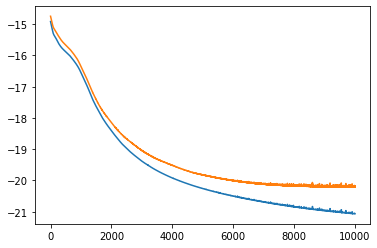

In [5]:
plt.plot(flows_dic[0]['losses'][0])
plt.plot(flows_dic[0]['losses'][1])

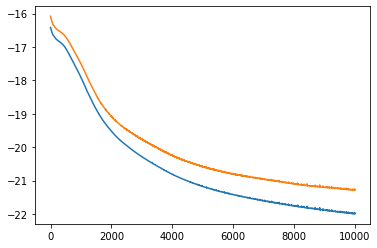

In [6]:
plt.plot(flows_dic[1]['losses'][0])
plt.plot(flows_dic[1]['losses'][1])

Final ratio mean: 6.495e-01
Final ratio mean: 6.131e-01


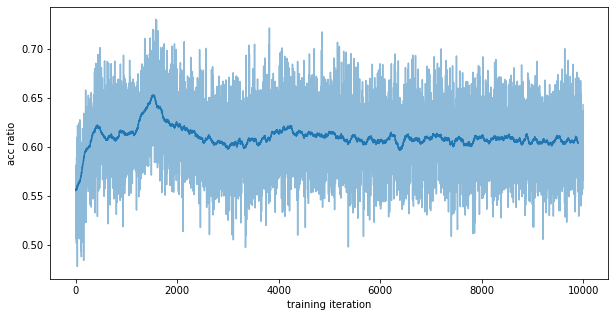

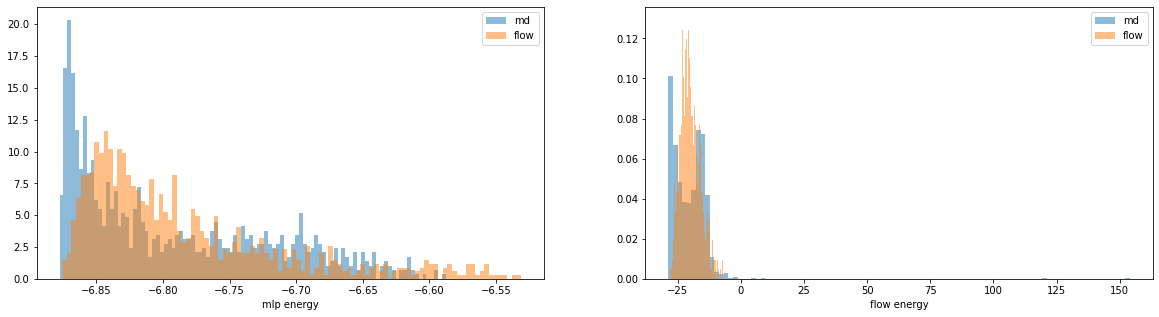

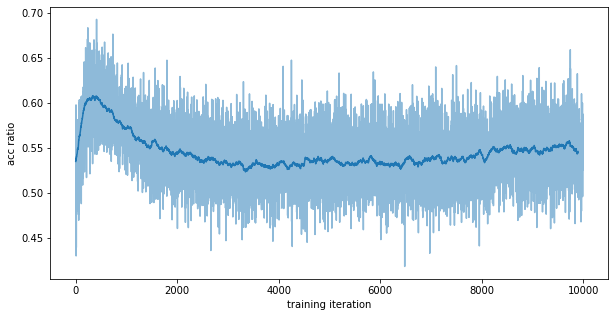

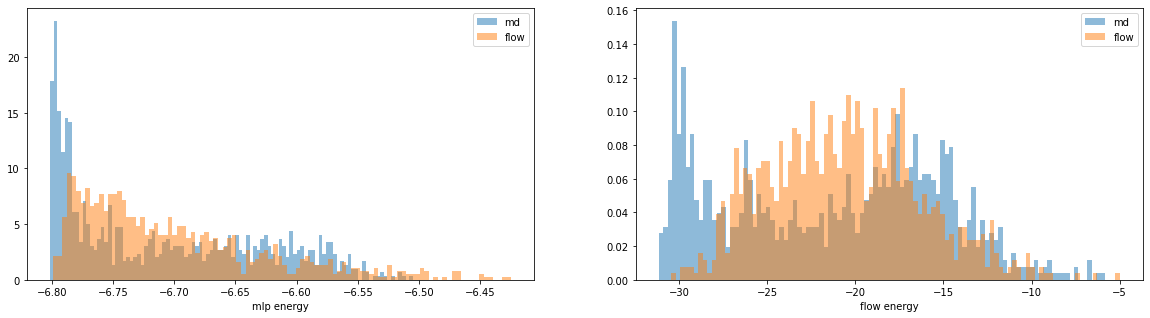

In [7]:

mode_labels = [0, 1]

for mode_label in mode_labels:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    test = join_data(xs_test,
                    energies_test,
                    zmat_test[:, 13],
                    logdetjacs_test,
    )

    n_chains = 1000
    init = test[:n_chains]
    ratio, acc = get_ratio_acc(flows[mode_label], init, init.shape[0], mlps[mode_label])
    print('Final ratio mean: {:.3e}'.format(ratio.mean()))

    plt.figure(figsize=(10,5))
    plt.plot(flows_dic[mode_label]['ratios'], alpha=0.5)
    plt.plot(moving_average(flows_dic[mode_label]['ratios'], 100), c='C0')
    plt.xlabel('training iteration')
    plt.ylabel('acc ratio')

    plt.figure(figsize=(20,5))
    xs_flow = flows[mode_label].sample(xs_test.shape[0])
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(mlps[mode_label](xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(flows[mode_label].nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(flows[mode_label].nll(xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('flow energy')
    plt.legend()

In [41]:
from flonacomldft.utils.diagnostics import get_participation_ratio

def get_participation_ratio(prop, target_log_prob, n_prop):
    xs = prop.sample(n_prop)
    log_weight = target_log_prob(xs).squeeze() + prop.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0) 
    return torch.exp(-log_ratio) / n_prop

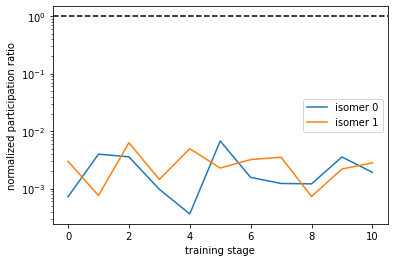

In [44]:
mode_labels = [0, 1]
n_prop = 5000

for mode_label in mode_labels:
    participations = []
    for model in flows_dic[mode_label]['models']:
        target_log_prob = lambda x: - mlps[mode_label](x) / (kb * T)
        participation = get_participation_ratio(model, target_log_prob, n_prop)
        participations.append(participation.item())
    plt.plot(participations, label='isomer {:d}'.format(mode_label))
plt.legend()
plt.xlabel('training stage')
plt.ylabel('normalized participation ratio')
# plt.ylim(0, 1)
plt.axhline(1, c='k', ls='--')
plt.yscale('log')


In [8]:
from flonacomldft.models.real_nvp import RealNVP_MLP
n_prop = 5000
model = RealNVP_MLP(12,
                    n_blocks=12,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    hidden_dim=128,  #128 #32
                    hidden_depth=4,  #4   #8
                    )
participation = get_participation_ratio(model, target_log_prob, n_prop)   
print(participation.item())     

0.0016744773602113128


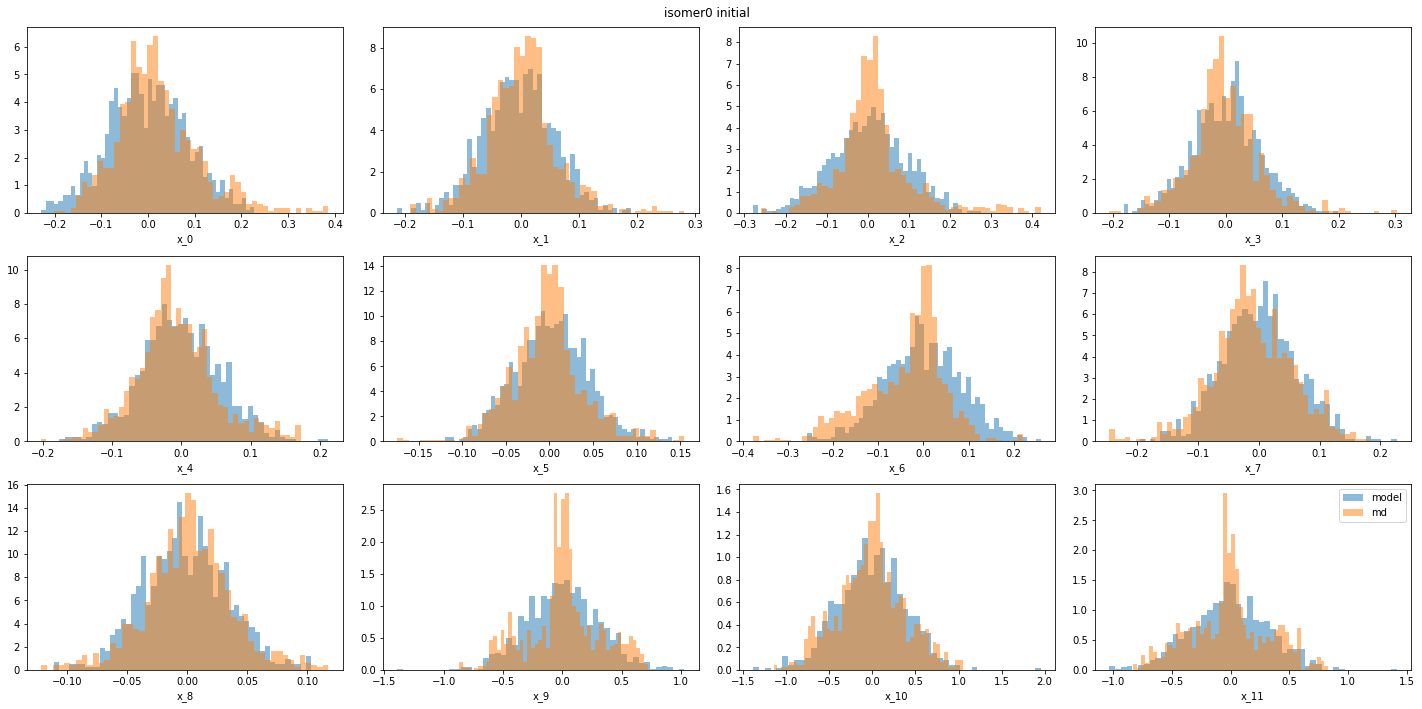

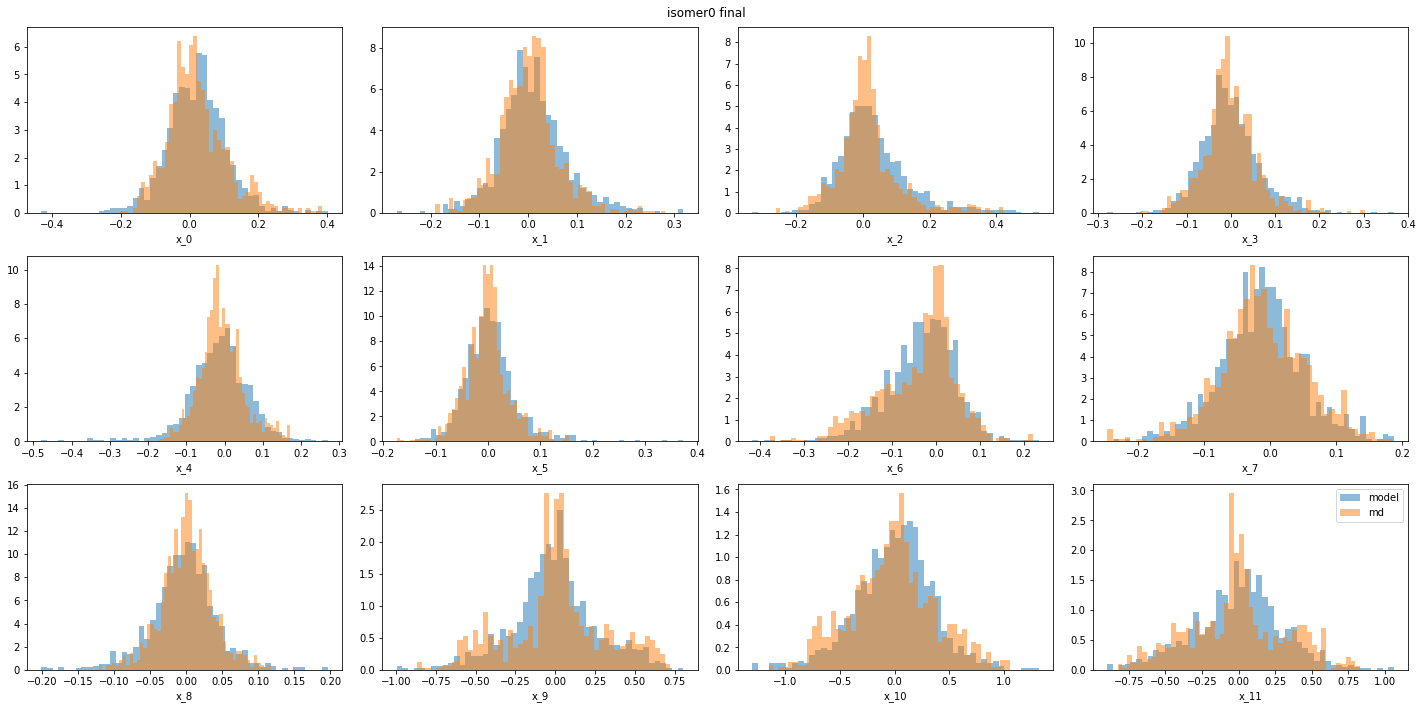

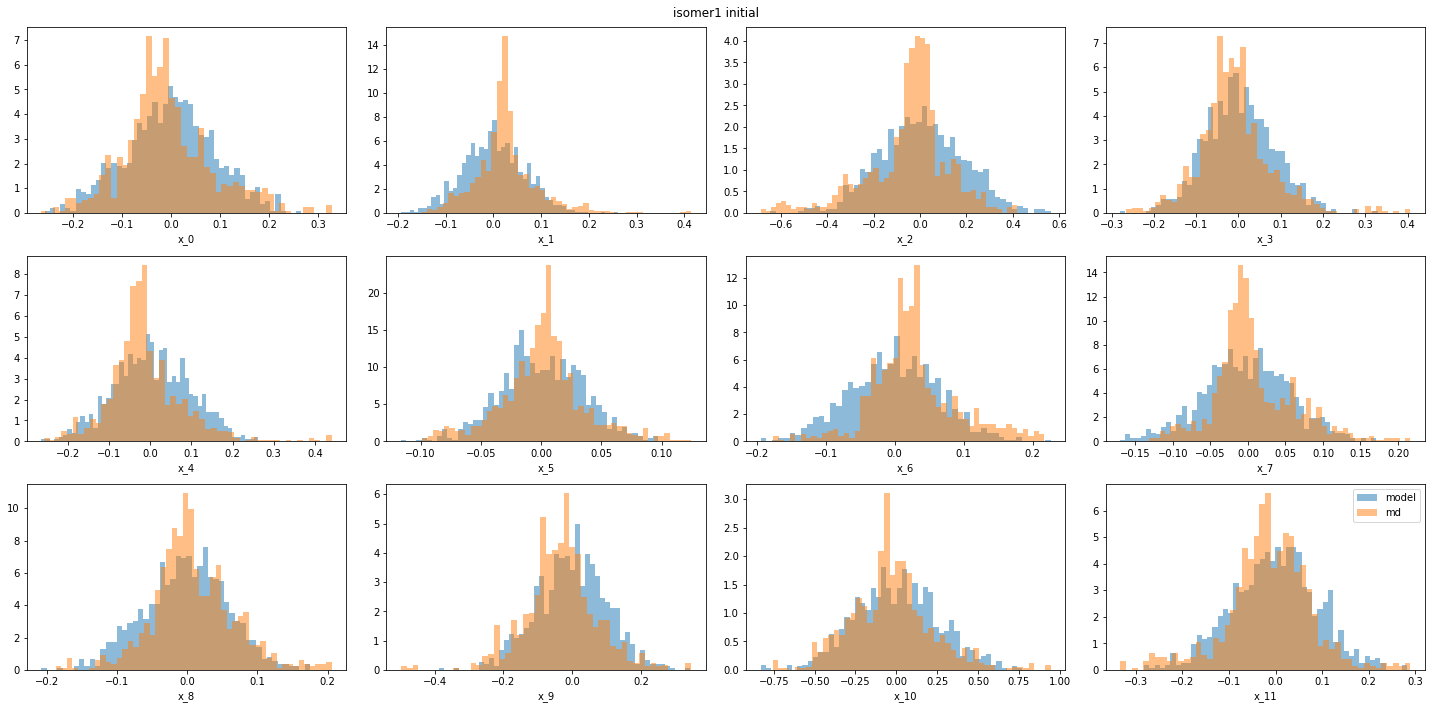

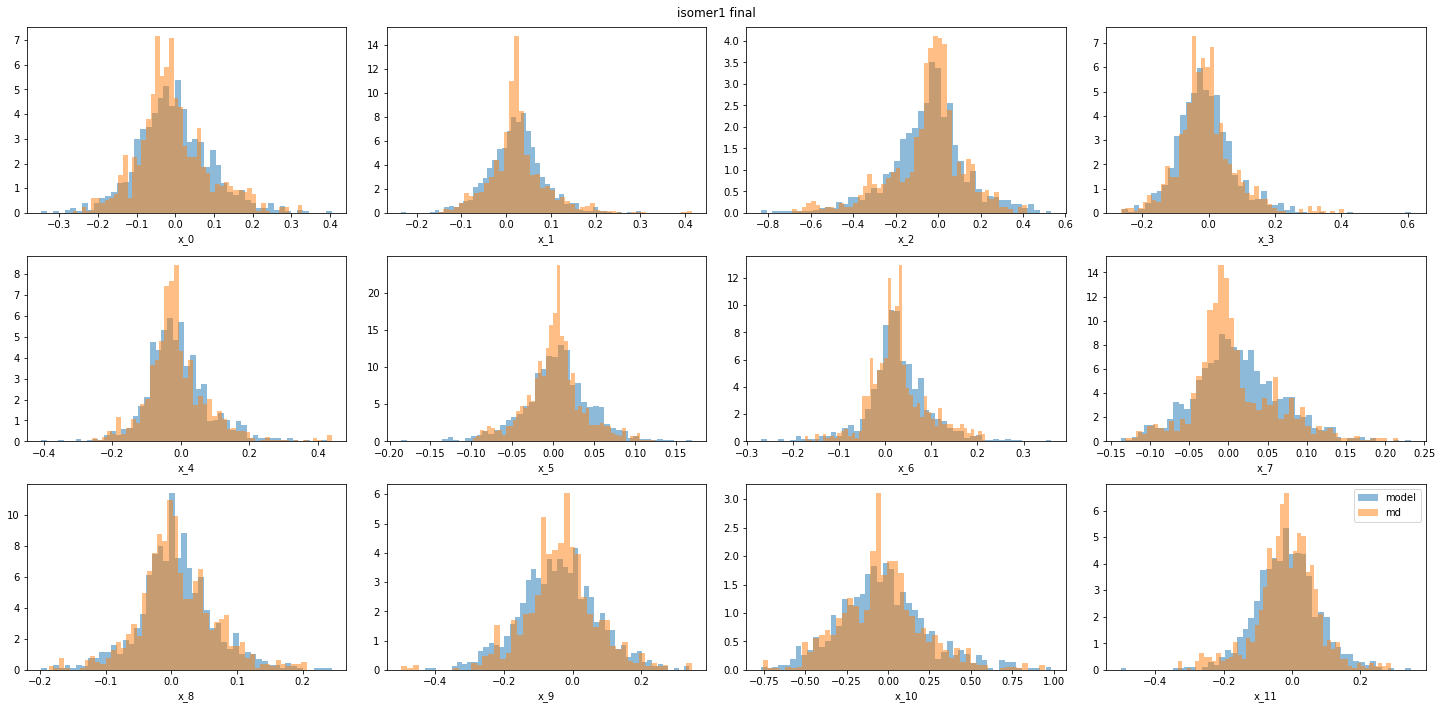

In [101]:
n_prop = 1000
for m in mode_labels:
    for training_stage, label in zip([0,-1], ['initial', 'final']):
        model = flows_dic[m]['models'][training_stage]
        x_prop = model.sample(n_prop)
        plt.figure(figsize=(20, 10))
        plt.suptitle('isomer' + str(m) + ' ' + label)
        axs = [plt.subplot(3, 4, i+1) for i in range(12)]
        for i in range(12):
            plt.sca(axs[i])
            plt.hist(x_prop[:, i].detach().numpy(), bins=50, alpha=0.5, density=True, label='model')
            plt.hist(x_mds[x_mds[:,13]==m][:n_prop, i].detach(), bins=50, alpha=0.5, density=True, label='md')
            plt.xlabel('x_{:d}'.format(i))
        plt.legend()
        plt.tight_layout()
        plt.show()



norm: 1.000e+00
participation: 1.444e-02


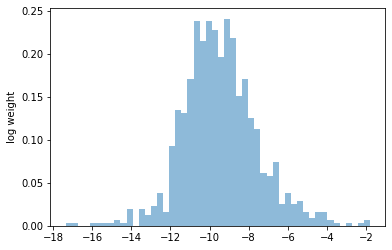

In [89]:
plt.figure()
log_weight = - mlps[0](x_prop).squeeze() / (kb * T) + model.nll(x_prop)
log_weight = log_weight - torch.logsumexp(log_weight, dim=0)
norm = np.sum(np.exp(log_weight.detach().numpy()))
plt.hist(log_weight.detach().numpy(), bins=50, alpha=0.5, density=True)
plt.ylabel('log weight')
print('norm: {:.3e}'.format(norm))
participation = torch.exp(- torch.logsumexp(2 * log_weight, dim=0)) / n_prop
print('participation: {:.3e}'.format(participation.item()))

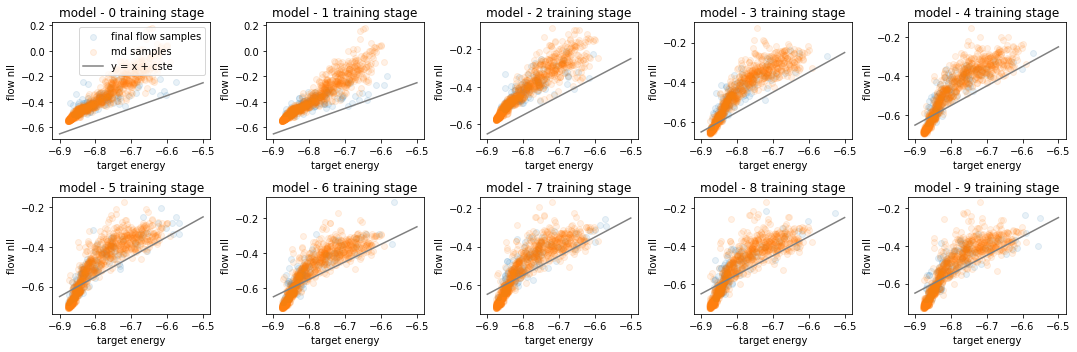

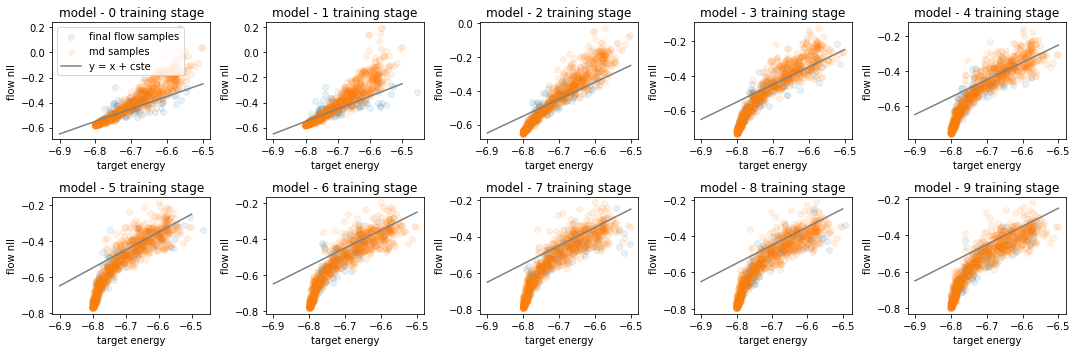

In [37]:

n_samples = 1000
for mode_label in mode_labels:
    plt.figure(figsize=(15,5))
    axes = [plt.subplot(2, 5, i + 1) for i in range(10)]
    # plt.suptitle('Samples from models projected on first two dimensions')
    models = [model for model in flows_dic[mode_label]['models']]
    x_test = x_mds[x_mds[:,13]==mode_label][:, :12]
    for m,model in enumerate(models[:10]):
        model.eval()
        plt.sca(axes[m])
        final_flow = models[m]
        xs_flow_final = final_flow.sample(100)

        plt.title('model - {:d} training stage'.format(int(m)))
        plt.scatter(mlps[mode_label](xs_flow_final[:n_samples]).detach().numpy(), final_flow.nll(xs_flow_final[:n_samples]).detach().numpy()/beta, alpha=0.1, label='final flow samples')
        plt.scatter(mlps[mode_label](x_test[:n_samples,:12]).detach().numpy(), final_flow.nll(x_test[:n_samples,:12]).detach().numpy()/beta, alpha=0.1, label='md samples')
        plt.plot(np.arange(-6.9, -6.5, 0.01), np.arange(-6.9, -6.5, 0.01) + 6.25 , c='grey', label='y = x + cste')
        plt.ylabel('flow nll')
        plt.xlabel('target energy')

        if m == 0:
            plt.legend()
    plt.tight_layout()
    plt.show()

# Dummy code for loading MD data and running MCMC 

In [ ]:

x_u_is_init = xs
# x_u_is_init[:, 14] 
# x_u_is_init.shape
mcmc_run = run_metropolis(mixture, init=x_u_is_init, n_chains=x_u_is_init.shape[0], n_steps=5, mixture=True, mlp_models=mlps_models, energy_type='mlp', with_tqdm=True)

In [10]:
mcmc_run.keys()

dict_keys(['xs', 'us', 'accs', 'isomers'])

# Computing the free energy differences

In [11]:
# target_log_probs = []
# for m in mode_labels:
#     target = lambda x: - mlps[m](x) / (kb * T)
#     target_log_probs.append(target)

target_log_probs = [lambda x: - mlps[0](x) / (kb * T), lambda x: - mlps[1](x) / (kb * T)]

In [22]:
blu = mlps[0](x_mds[:,:12][x_mds[:,13] == 0]).squeeze().detach().numpy()
bla = mlps[1](x_mds[:,:12][x_mds[:,13] == 1]).squeeze().detach().numpy()

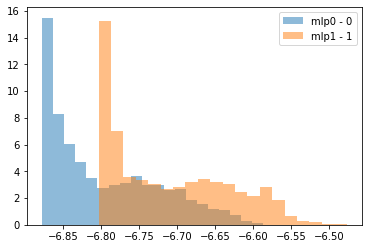

In [27]:
plt.hist(blu,bins=20, alpha=0.5, density=True, label='mlp0 - 0')
plt.hist(bla,bins=20, alpha=0.5, density=True, label='mlp1 - 1')

plt.legend()

## Targeted free energy perturbation

[-246.98160038431203, -243.83404789407766]
[-246.6557642026714, -242.19392643411672]
[-246.6080804868511, -243.11105595071828]
[-246.37494144876516, -242.85220585306203]
[-246.61213932474172, -244.77888737161672]
[-246.4682642026714, -242.64401493509328]
[-248.13267765481984, -242.9672113462261]
[-246.46596012552297, -242.41571293314016]
[-247.11087284524953, -242.89535770853078]
[-246.6921869321636, -242.0732904477886]
log_ratio_TFPs: -3.834e+00 +/- 8.752e-01 log_err_TFPs: nan +/- nan


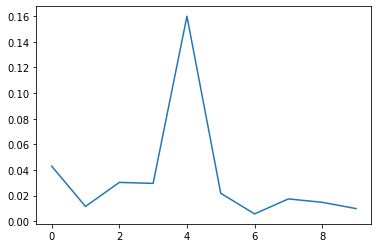

In [13]:
n_prop = 4000
mix_prop = flows

log_ratio_TFPs = []
log_err_TFPs = []
for trial in range(10):
    log_ratio_TFP, log_err_TFP, logrs = compute_TFP_logratio(n_prop, target_log_probs, mix_prop)

    log_ratio_TFPs.append(log_ratio_TFP)
    log_err_TFPs.append(log_err_TFP)
    print(logrs)

log_ratio_TFPs = np.array(log_ratio_TFPs)
log_err_TFPs = np.array(log_err_TFPs)

print(
    'log_ratio_TFPs: {:.3e} +/- {:.3e}'.format(log_ratio_TFPs.mean(), log_ratio_TFPs.std()),
    'log_err_TFPs: {:.3e} +/- {:.3e}'.format(log_err_TFPs.mean(), log_err_TFPs.std())
)
plt.plot(np.exp(log_ratio_TFPs))

## BAR with MD data

In [14]:
xs = x_mds[:, :12]
isomers = x_mds[:, 13]


log_ratio_deepBARs = []
log_err_deepBARs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_deepBAR, logrs = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_deepBARs.append(log_ratio_deepBAR)
    log_err_deepBARs.append(log_err_deepBAR)
    print(logrs)

log_ratio_deepBARs = np.array(log_ratio_deepBARs)
log_err_deepBARs = np.array(log_err_deepBARs)

print(
    'log_ratio_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBARs.mean(), log_ratio_deepBARs.std()),
    'log_err_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_deepBARs.mean(), log_err_deepBARs.std())
)

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:168: UserWarning: Error estimation misses ESS estimation
  warnings.warn("Error estimation misses ESS estimation")
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.1194730689112475e-05 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.18375083452338e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.57238770131968, -242.68953367142885]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.5315110008250485e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.1359551024270331e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.11065664201845, -242.08597500339187]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.3332465584880993e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.8160206372594985e-07 reached.
  warnings.warn(msg, RuntimeWarning)


...

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -7.202779670478776e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -4.132932929223898e-07 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.95858996362594, -242.58483388407808]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.6578712518366956e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.89308780003012, -243.42601285769712]
log_ratio_deepBARs: -4.074e+00 +/- 3.763e-01 log_err_deepBARs: 6.119e-01 +/- 1.717e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.0277871303496795e-06 reached.
  warnings.warn(msg, RuntimeWarning)


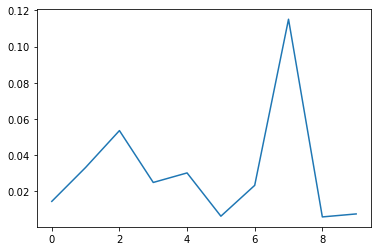

In [46]:
plt.plot(np.exp(log_ratio_deepBARs))

## BAR with MCMC data

In [54]:
x_u_is_init = torch.cat((x_mds[:50], x_mds[-50:]))
x_u_is_init.shape
x_u_is_init[:, 13] 

mcmc_run = run_metropolis(mixture, init=x_u_is_init, n_chains=x_u_is_init.shape[0], n_steps=80, mixture=True, mlp_models=mlps, energy_type='mlp', with_tqdm=True)

acc: 0.10: 100%|██████████| 80/80 [00:25<00:00,  3.10it/s]


In [56]:
xs = mcmc_run['xs'].reshape(-1, 12)
isomers = mcmc_run['isomers'].reshape(-1)

log_ratio_deepBAR_MCMCs = []
log_err_deepBAR_MCMCs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_deepBAR, logrs = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_deepBAR_MCMCs.append(log_ratio_deepBAR)
    log_err_deepBAR_MCMCs.append(log_err_deepBAR)
    print(logrs)
    
log_ratio_deepBAR_MCMCs = np.array(log_ratio_deepBAR_MCMCs)
log_err_deepBAR_MCMCs = np.array(log_err_deepBAR_MCMCs)

print(
    'log_ratio_deepBAR_MCMCs: {:.3e} +/- {:.3e}'.format(log_ratio_deepBAR_MCMCs.mean(), log_ratio_deepBAR_MCMCs.std()),
    'log_err_deepBAR_MCMCs: {:.3e} +/- {:.3e}'.format(log_err_deepBAR_MCMCs.mean(), log_err_deepBAR_MCMCs.std())
)

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:167: UserWarning: Error estimation misses ESS estimation
  ess = 1
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 7.296428350400674e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 3.477909672255919e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.61538087613667, -242.32170205906462]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 8.347230107119685e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 3.056386447042314e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-248.63602365161415, -241.63728475065906]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 2.283552674953171e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.6835021717251948e-06 reached.
  warnings.warn(msg, RuntimeWarning)


...

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -1.1598882508678798e-05 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.5105965758266393e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-247.30700686047774, -241.4959887229627]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 5.807657259992993e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-246.6758915109496, -244.17382403143026]
log_ratio_deepBAR_MCMCs: -4.588e+00 +/- 1.246e+00 log_err_deepBAR_MCMCs: 7.628e-01 +/- 1.599e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.8059211015497567e-06 reached.
  warnings.warn(msg, RuntimeWarning)


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/numpy/core/_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


([<matplotlib.axis.XTick at 0x7fccac99c970>,
 [Text(1, 0, 'TFP '),
  Text(2, 0, 'BAR MD'),
  Text(3, 0, 'BAR MCMC'),
  Text(4, 0, 'frac_mcmc')])

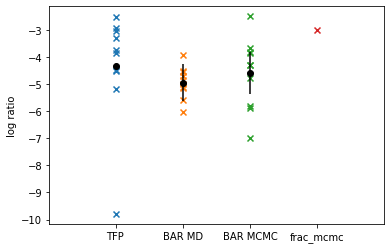

In [70]:
plt.scatter(np.ones(10), log_ratio_TFPs, marker='x')
plt.errorbar([1], np.array(log_ratio_TFPs).mean(), yerr=np.array(log_err_TFPs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 2, log_ratio_deepBARs, marker='x')
plt.errorbar([2], np.array(log_ratio_deepBARs).mean(), yerr=np.array(log_err_deepBARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 3, log_ratio_deepBAR_MCMCs, marker='x')
plt.errorbar([3], np.array(log_ratio_deepBAR_MCMCs).mean(), yerr=np.array(log_err_deepBAR_MCMCs).mean(), marker='o', color='k')

frac_mcmc = mcmc_run['isomers'][-20:].sum() / (1 - mcmc_run['isomers'][-20:]).sum()

plt.scatter([4], np.log(frac_mcmc.detach().numpy()), marker='x')

plt.xlim(0,5)
plt.ylabel('log ratio')
plt.xticks([1,2,3, 4], ['TFP ', 'BAR MD', 'BAR MCMC', 'frac_mcmc'])

# Taking first logged models and compare estimators

/Users/marylou/Dropbox/Prof/Experiments/ml-dft/ML-DFT/packages/flonaco-ml-dft/flonacomldft/free_energy_computations.py:39: RuntimeWarning: overflow encountered in exp
  logr_err = np.var(np.exp(logprob_target - logprob_prop)) / (logr ** 2) / n_prop
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/numpy/core/_methods.py:229: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


[-250.4838129087261, -245.41806278665578]
[-251.05894718606984, -245.73037968118703]
[-249.90608463724172, -245.16494999368703]
[-250.25618229349172, -244.8324457212261]
[-249.63307438333547, -245.21426639993703]
[-250.50636539896047, -244.51700077493703]
[-251.6313959165386, -245.96922550638234]
[-249.63853702981984, -245.55690250833547]
[-249.65855656106984, -245.46303043802297]
[-250.49739323099172, -245.44912968118703]
log_ratio_untrained_TFPs: -4.995e+00 +/- 6.006e-01 log_err_untrained_TFPs: nan +/- nan


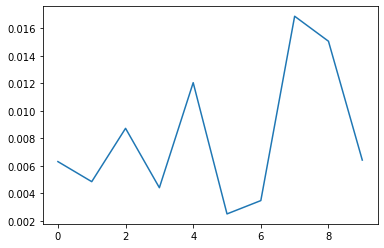

In [27]:
n_prop = 4000
mix_prop = [flows_dic[0]['models'][0], flows_dic[1]['models'][0]]

log_ratio_untrained_TFPs = []
log_err_untrained_TFPs = []
for trial in range(10):
    log_ratio_TFP, log_err_TFP, logrs = compute_TFP_logratio(n_prop, target_log_probs, mix_prop)

    log_ratio_untrained_TFPs.append(log_ratio_TFP)
    log_err_untrained_TFPs.append(log_err_TFP)
    print(logrs)


log_ratio_untrained_TFPs = np.array(log_ratio_untrained_TFPs)
log_err_untrained_TFPs = np.array(log_err_untrained_TFPs)

print(
    'log_ratio_untrained_TFPs: {:.3e} +/- {:.3e}'.format(log_ratio_untrained_TFPs.mean(), log_ratio_untrained_TFPs.std()),
    'log_err_untrained_TFPs: {:.3e} +/- {:.3e}'.format(log_err_untrained_TFPs.mean(), log_err_untrained_TFPs.std())
)
plt.plot(np.exp(log_ratio_untrained_TFPs))

In [20]:
xs = x_mds[:, :12]
isomers = x_mds[:, 13]
mix_prop = [flows_dic[0]['models'][0], flows_dic[1]['models'][0]]

log_ratio_untrained_deepBARs = []
log_err_untrained_deepBARs = []

for trial in range(10):
    log_ratio_deepBAR, log_err_untrained_deepBAR, logrs = compute_deepBAR_logratio(xs, isomers, target_log_probs, mix_prop)

    log_ratio_untrained_deepBARs.append(log_ratio_deepBAR)
    log_err_untrained_deepBARs.append(log_err_untrained_deepBAR)
    print(logrs)

log_ratio_untrained_deepBARs = np.array(log_ratio_untrained_deepBARs)
log_err_untrained_deepBARs = np.array(log_err_untrained_deepBARs)

print(
    'log_ratio_untrained_deepBARs: {:.3e} +/- {:.3e}'.format(log_ratio_untrained_deepBARs.mean(), log_ratio_untrained_deepBARs.std()),
    'log_err_untrained_deepBARs: {:.3e} +/- {:.3e}'.format(log_err_untrained_deepBARs.mean(), log_err_untrained_deepBARs.std())
)

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.6251261456545762e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.5723687738500303e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-249.69831404185857, -245.80510401938938]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 2.664226030901773e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 1.3859536522886629e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-250.38786551145228, -244.87201155408422]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -2.4979394197544025e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -8.468350927159918e-06 reached.
  warnings.warn(msg, RuntimeWarning)


...

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 8.92943489816389e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of 3.3503585825656046e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-249.8722101022835, -245.67226947108264]


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -3.361058702466835e-06 reached.
  warnings.warn(msg, RuntimeWarning)


[-250.12520086855588, -245.4947081561744]
log_ratio_untrained_deepBARs: -4.911e+00 +/- 5.890e-01 log_err_untrained_deepBARs: 6.260e-01 +/- 2.483e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/_zeros_py.py:349: RuntimeWarning: Tolerance of -1.9460588021047442e-06 reached.
  warnings.warn(msg, RuntimeWarning)


([<matplotlib.axis.XTick at 0x7fc45aee2280>,
 [Text(1, 0, 'TFP '),
  Text(2, 0, 'TFP init'),
  Text(3, 0, 'deepBAR MD'),
  Text(4, 0, 'deepBAR MD init')])

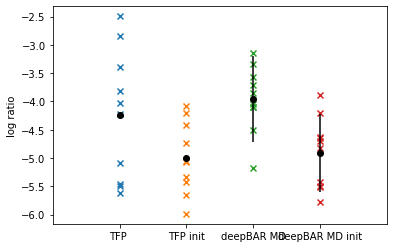

In [29]:
plt.scatter(np.ones(10), log_ratio_TFPs, marker='x')
plt.errorbar([1], np.array(log_ratio_TFPs).mean(), yerr=np.array(log_err_TFPs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 2, log_ratio_untrained_TFPs, marker='x')
plt.errorbar([2], np.array(log_ratio_untrained_TFPs).mean(), yerr=np.array(log_err_untrained_TFPs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 3, log_ratio_deepBARs, marker='x')
plt.errorbar([3], np.array(log_ratio_deepBARs).mean(), yerr=np.array(log_err_deepBARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 4, log_ratio_untrained_deepBARs, marker='x')
plt.errorbar([4], np.array(log_ratio_untrained_deepBARs).mean(), yerr=np.array(log_err_untrained_deepBAR).mean(), marker='o', color='k')

# frac_mcmc = mcmc_run['isomers'][-20:].sum() / (1 - mcmc_run['isomers'][-20:]).sum()

# plt.scatter([4], np.log(frac_mcmc.detach().numpy()), marker='x')

plt.xlim(0,5)
plt.ylabel('log ratio')
plt.xticks([1, 2, 3, 4], ['TFP ', 'TFP init', 'deepBAR MD', 'deepBAR MD init'])

# Per isomer test

In [29]:
n_prop = 8000
prop = get_models(flows_dic)[0]
target_log_prob = lambda x: - mlps[0](x) / (kb * T)

log_ratio_0_TFPs = []
log_err_0_TFPs = []

for trial in range(10):
    logr_TFP_0, log_err_TFP_0 = compute_TFP(n_prop, target_log_prob, prop)
    log_ratio_0_TFPs.append(logr_TFP_0)
    log_err_0_TFPs.append(log_err_TFP_0)

print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_TFPs).mean(), np.array(log_ratio_0_TFPs).std()))

logr_TFP -2.471e+02 +/- 3.935e-01


In [33]:
n_prop = 8000
prop = get_models(flows_dic)[1]
target_log_prob = lambda x: - mlps[1](x) / (kb * T)

log_ratio_1_TFPs = []
log_err_1_TFPs = []

for trial in range(10):
    logr_TFP_1, log_err_TFP_1 = compute_TFP(n_prop, target_log_prob, prop)
    log_ratio_1_TFPs.append(logr_TFP_1)
    log_err_1_TFPs.append(log_err_TFP_1)

print('logr_TFP {:.3e} +/- {:.3e}'.format(np.array(log_ratio_1_TFPs).mean(), np.array(log_ratio_1_TFPs).std()))

logr_TFP -2.434e+02 +/- 6.736e-01


In [32]:
n_prop = 8000
prop = get_models(flows_dic)[0]
target_log_prob = lambda x: - mlps[0](x) / (kb * T)
xs = x_mds[:, :12][x_mds[:, 13] == 0]

log_ratio_0_BARs = []
log_err_0_BARs = []

for trial in range(10):
    logr_BAR_0, log_err_BAR_0 = compute_BAR(xs, target_log_prob, prop, n_prop)
    log_ratio_0_BARs.append(logr_BAR_0)
    log_err_0_BARs.append(log_err_BAR_0)

print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_BARs).mean(), np.array(log_ratio_0_BARs).std()))

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.708417438019751e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -2.480957448369736e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.2814723504561698e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.8206999925496348e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.787388413276858e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users

logr_BAR -2.472e+02 +/- 6.996e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.0639877479643474e-06 reached.
  warnings.warn(msg, RuntimeWarning)


In [35]:
n_prop = 8000
prop = get_models(flows_dic)[1]
target_log_prob = lambda x: - mlps[1](x) / (kb * T)
xs = x_mds[:, :12][x_mds[:, 13] == 1]

log_ratio_1_BARs = []
log_err_1_BARs = []

for trial in range(10):
    logr_BAR_1, log_err_BAR_1 = compute_BAR(xs, target_log_prob, prop, n_prop)
    log_ratio_1_BARs.append(logr_BAR_1)
    log_err_1_BARs.append(log_err_BAR_1)

print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_1_BARs).mean(), np.array(log_ratio_1_BARs).std()))

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -1.0713127096551034e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 4.692328161581827e-07 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.4204190342279617e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.832677895663437e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 3.0316053880596883e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/User

logr_BAR -2.430e+02 +/- 6.383e-01


/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.996203081944259e-06 reached.
  warnings.warn(msg, RuntimeWarning)


([<matplotlib.axis.XTick at 0x7fcd2c7a5550>,
 [Text(1, 0, 'BAR 0'),
  Text(2, 0, 'TFP 0'),
  Text(3, 0, 'BAR 1'),
  Text(4, 0, 'TFP 1')])

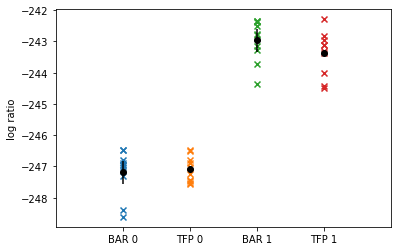

In [36]:
plt.scatter(np.ones(10), log_ratio_0_BARs, marker='x')
plt.errorbar([1], np.array(log_ratio_0_BARs).mean(), yerr=np.array(log_err_0_BARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 2, log_ratio_0_TFPs, marker='x')
plt.errorbar([2], np.array(log_ratio_0_TFPs).mean(), yerr=np.array(log_err_0_TFPs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 3, log_ratio_1_BARs, marker='x')
plt.errorbar([3], np.array(log_ratio_1_BARs).mean(), yerr=np.array(log_err_1_BARs).mean(), marker='o', color='k')

plt.scatter(np.ones(10) * 4, log_ratio_1_TFPs, marker='x')
plt.errorbar([4], np.array(log_ratio_1_TFPs).mean(), yerr=np.array(log_err_1_TFPs).mean(), marker='o', color='k')

plt.xlim(0,5)
plt.ylabel('log ratio')
plt.xticks([1,2,3,4], ['BAR 0', 'TFP 0', 'BAR 1', 'TFP 1'])
# plt.plot(np.exp(log_ratio_0_TFPs))
# plt.xlabel('trial')
# plt.ylabel('ratio model - data')

# Error estimations

## deep bar -> need to add the ESS

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 2.945534760101509e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 4.184157404552025e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 3.636684709817928e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of -3.393351335034822e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/scipy/optimize/zeros.py:341: RuntimeWarning: Tolerance of 1.9302251530461945e-06 reached.
  warnings.warn(msg, RuntimeWarning)
/Users/m

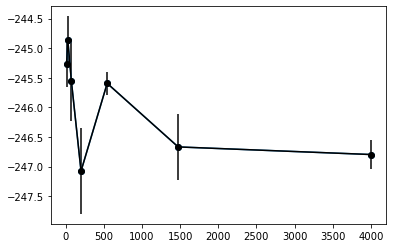

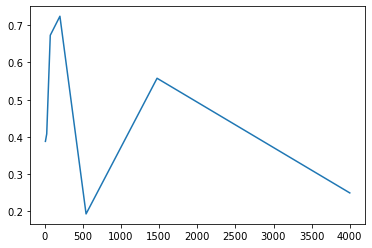

In [89]:

prop = get_models(flows_dic)[0]
target_log_prob = lambda x: - mlps[0](x) / (kb * T)
xs = x_mds[:, :12][x_mds[:, 13] == 0]

log_ratio_0_BARs = []
log_err_0_BARs = []

n_props = np.logspace(1, np.log(4000)/np.log(10) , 7)
for n_prop in n_props:
    n_prop = int(n_prop)
    logr_BAR_0, log_err_BAR_0 = compute_BAR(xs[:n_prop], target_log_prob, prop, n_prop)
    log_ratio_0_BARs.append(logr_BAR_0)
    log_err_0_BARs.append(log_err_BAR_0)

plt.figure()
plt.plot(n_props, log_ratio_0_BARs, marker='o')
plt.errorbar(n_props, log_ratio_0_BARs, yerr=log_err_0_BARs, marker='o', color='k')
plt.figure()
plt.plot(n_props, log_err_0_BARs)
# print('logr_BAR {:.3e} +/- {:.3e}'.format(np.array(log_ratio_0_BARs).mean(), np.array(log_ratio_0_BARs).std()))

# Looking at acceptances within modes

Untrained:

initial ratio mean: 5.886e-01
initial ratio mean: 5.312e-01


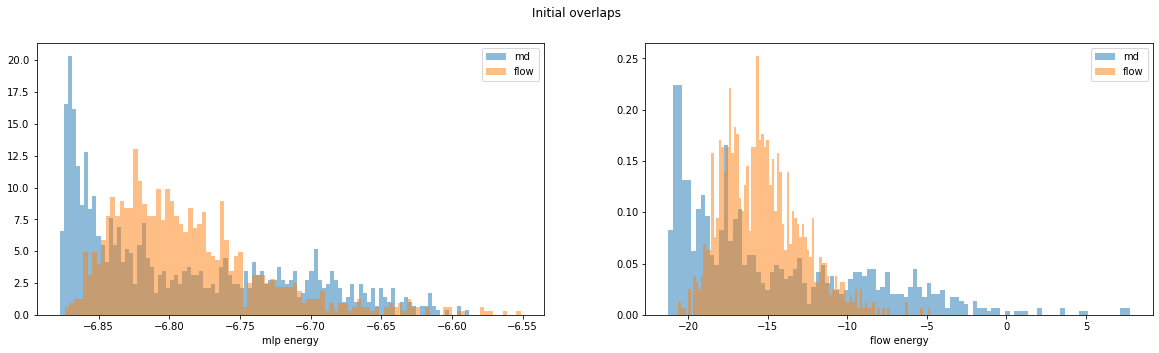

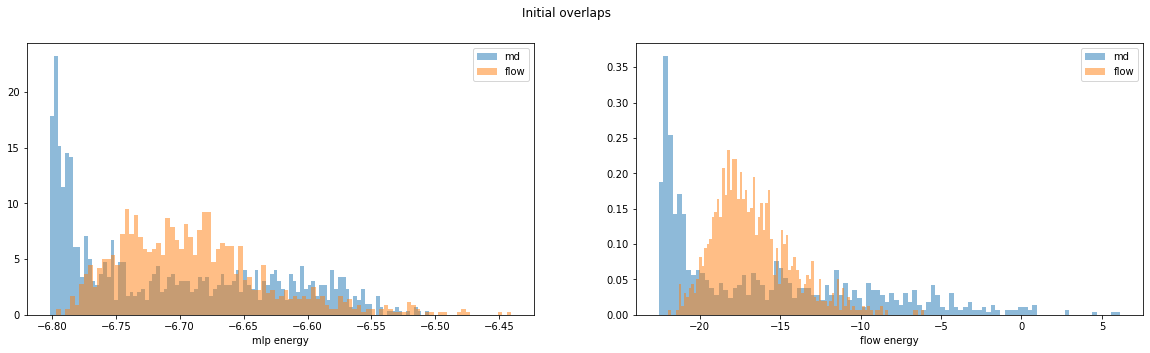

In [68]:
for mode_label in [0, 1]:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    test = join_data(xs_test,
                    energies_test,
                    zmat_test[:, 13],
                    logdetjacs_test,
    )

    n_chains = 1000
    init = test[:n_chains]
    
    init_flow = flows_dic[mode_label]['models'][0]

    ratio, acc = get_ratio_acc(init_flow, init, init.shape[0], mlps[mode_label])
    print('initial ratio mean: {:.3e}'.format(ratio.mean()))

    plt.figure(figsize=(20,5))
    plt.suptitle('Initial overlaps')
    xs_flow = init_flow.sample(xs_test.shape[0])
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(mlps[mode_label](xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(init_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='md')
    plt.hist(init_flow.nll(xs_flow).detach().numpy(), bins=100, alpha=0.5, density=True, label='flow')
    plt.xlabel('flow energy')
    plt.legend()

Comparing the flows energy distribution after training

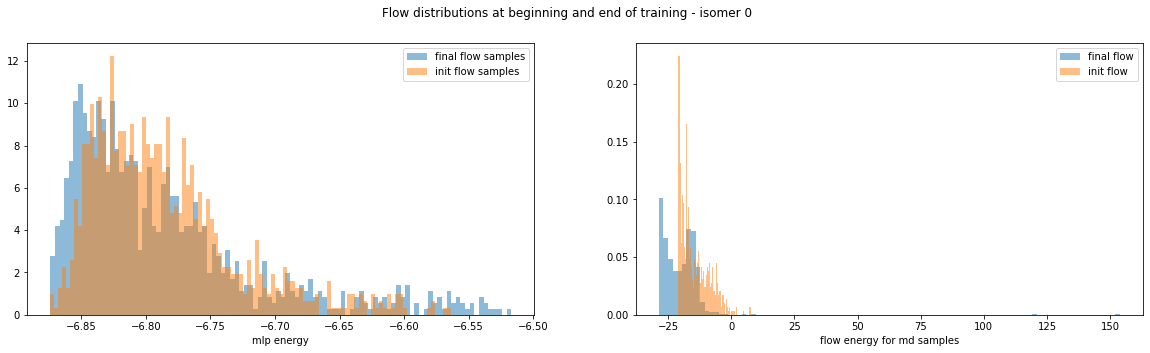

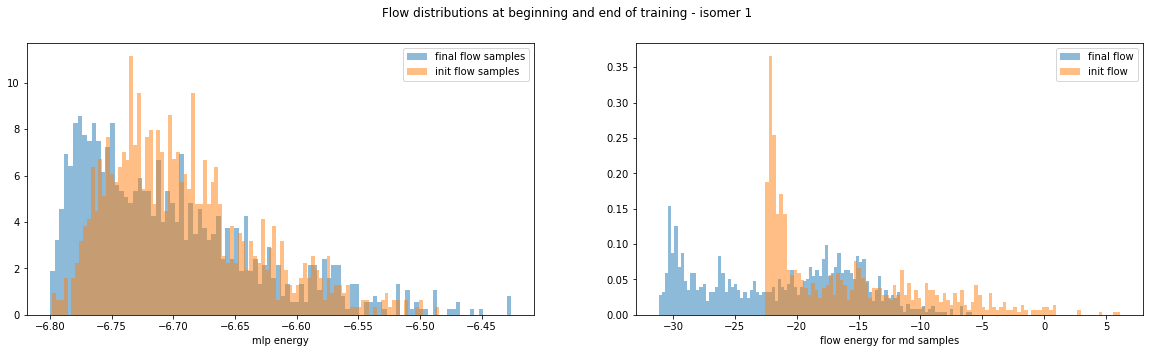

In [73]:
for mode_label in [0, 1]:
    zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

    xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                        zmat_test[:, :12],
                                        isomer=mode_label,
                                        energies=zmat_test[:, 12],
                                        logdetjacs=zmat_test[:, 14],
                                        )
    xs_test = xs_test.to(torch.float32)
    
    init_flow = flows_dic[mode_label]['models'][0]
    final_flow = flows[mode_label]

    n_chains = 1000

    plt.figure(figsize=(20,5))
    plt.suptitle('Flow distributions at beginning and end of training - isomer {:d}'.format(mode_label))
    xs_flow_init = init_flow.sample(n_chains)
    xs_flow_final = final_flow.sample(n_chains)
    ax = plt.subplot(1,2,1)
    plt.hist(mlps[mode_label](xs_flow_final).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow samples')
    plt.hist(mlps[mode_label](xs_flow_init).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow samples')
    plt.xlabel('mlp energy')
    plt.legend()
    ax = plt.subplot(1,2,2)
    plt.hist(final_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='final flow')
    plt.hist(init_flow.nll(xs_test).detach().numpy(), bins=100, alpha=0.5, density=True, label='init flow')
    plt.xlabel('flow energy for md samples')
    plt.legend()

acc: 0.08: 100%|██████████| 100/100 [00:12<00:00,  8.24it/s]


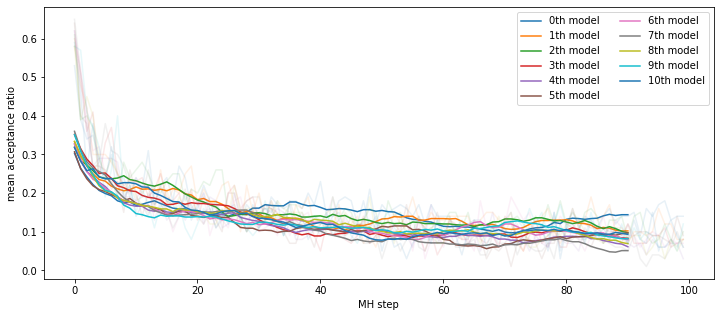

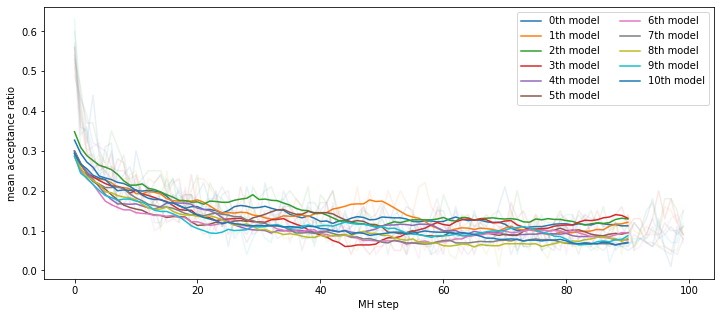

In [14]:
for mode_label in [0, 1]:
    mcmc_runs = []
    for flow in flows_dic[mode_label]['models']:
        zmat_test = load_csv_file("datasets/is{:d}_md_test.csv".format(mode_label))

        xs_test, logdetjacs_test, energies_test = coord_mapping.get_real_centered_from_internal(
                                            zmat_test[:, :12],
                                            isomer=mode_label,
                                            energies=zmat_test[:, 12],
                                            logdetjacs=zmat_test[:, 14],
                                            )
        xs_test = xs_test.to(torch.float32)
        test = join_data(xs_test,
                        energies_test,
                        zmat_test[:, 13],
                        logdetjacs_test,
        )

        n_chains = 100
        init = test[:n_chains]
        mcmc_run = run_metropolis(flow, init, init.shape[0], n_steps=100, energy_type='mlp', mlp_models=mlps[mode_label], with_tqdm=True)
        mcmc_runs.append(mcmc_run)

    plt.figure(figsize=(12,5))
    for d,mcmc_run in enumerate(mcmc_runs):
        _ = plt.plot((mcmc_run['accs'] * 1.).mean(1), alpha=0.1)
        plt.plot(moving_average((mcmc_run['accs'] * 1.).mean(1), 10), c=_[0].get_color(), label='{:d}th model'.format(d))
    plt.xlabel('MH step')
    plt.ylabel('mean acceptance ratio')
    plt.legend(ncol=2)

In [16]:
mcmc_run

{'xs': tensor([[[ 1.8364e-01,  1.0091e-01,  1.1103e-01,  ...,  3.4838e-02,
            1.1393e-02,  5.5679e-02],
          [-9.5002e-03, -1.6683e-02, -2.1890e-01,  ..., -2.3200e-01,
           -4.7658e-02, -5.4776e-02],
          [ 2.6339e-01, -7.7515e-02,  1.6198e-01,  ...,  2.4702e-01,
            8.5177e-01,  1.8135e-01],
          ...,
          [-9.5313e-02,  4.4864e-02, -2.1700e-01,  ..., -2.4884e-01,
           -4.0803e-01, -1.6328e-02],
          [-8.8756e-02, -9.0077e-03, -3.0020e-01,  ..., -1.0160e-01,
           -2.4941e-01,  1.6343e-02],
          [ 3.9465e-03,  7.8096e-02,  1.4565e-02,  ...,  1.0391e-02,
           -5.7536e-02,  2.0181e-02]],
 
         [[ 1.8364e-01,  1.0091e-01,  1.1103e-01,  ...,  3.4838e-02,
            1.1393e-02,  5.5679e-02],
          [-9.5002e-03, -1.6683e-02, -2.1890e-01,  ..., -2.3200e-01,
           -4.7658e-02, -5.4776e-02],
          [-1.1325e-02, -3.7701e-02,  3.0420e-01,  ..., -1.0211e-01,
            3.0194e-01,  8.8576e-02],
          ...

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


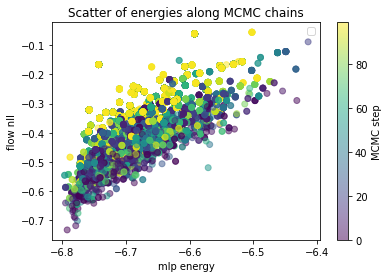

In [38]:
xs = mcmc_run['xs']
plt.title('Scatter of energies along MCMC chains')
steps = 100
for chain in range(100):
    # plt.plot(mlps[mode_label](xs[chain][:steps]).detach().numpy(), - final_flow.log_prob(xs[chain][:steps]).detach().numpy()/beta, '-', alpha=0.5, label='inital flow samples')
    plt.scatter(mlps[mode_label](xs[:steps, chain, :]).detach().numpy(),final_flow.nll(xs[:steps, chain, :]).detach().numpy()/beta,  c=np.arange(steps), cmap='viridis', alpha=0.5)
plt.colorbar(label='MCMC step')
# plt.plot(mlps[mode_label](x_test[:,:12]).detach().numpy(), - init_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='md samples')
plt.ylabel('flow nll')
plt.xlabel('mlp energy')
plt.legend()

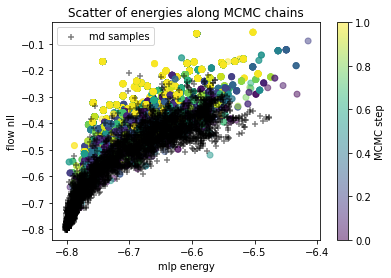

In [39]:
xs = mcmc_run['xs']
x_md = x_mds[x_mds[:, 13] == mode_label][:, :12]
plt.title('Scatter of energies along MCMC chains')
steps = 100
for chain in range(100):
    # plt.plot(mlps[mode_label](xs[chain][:steps]).detach().numpy(), - final_flow.log_prob(xs[chain][:steps]).detach().numpy()/beta, '-', alpha=0.5, label='inital flow samples')
    plt.scatter(mlps[mode_label](xs[:steps, chain, :]).detach().numpy(),final_flow.nll(xs[:steps, chain, :]).detach().numpy()/beta,  c=np.arange(steps), cmap='viridis', alpha=0.5)
plt.scatter(mlps[mode_label](x_md).detach().numpy(), final_flow.nll(x_md).detach().numpy()/beta, marker='+', c='k', alpha=0.5, label='md samples')
plt.colorbar(label='MCMC step')
# plt.plot(mlps[mode_label](x_test[:,:12]).detach().numpy(), - init_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='md samples')
plt.ylabel('flow nll')
plt.xlabel('mlp energy')
plt.legend()

Text(0, 0.5, 'mlp energy')

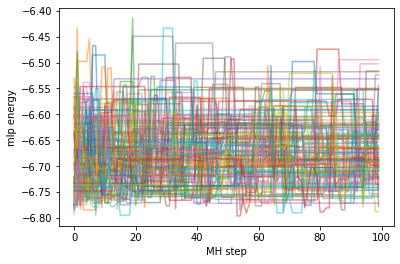

In [23]:
plt.plot((mcmc_run['us'][:, :]).detach().numpy(), alpha=0.5)
plt.xlabel('MH step')
plt.ylabel('mlp energy')

Text(0.5, 0, 'MH step')

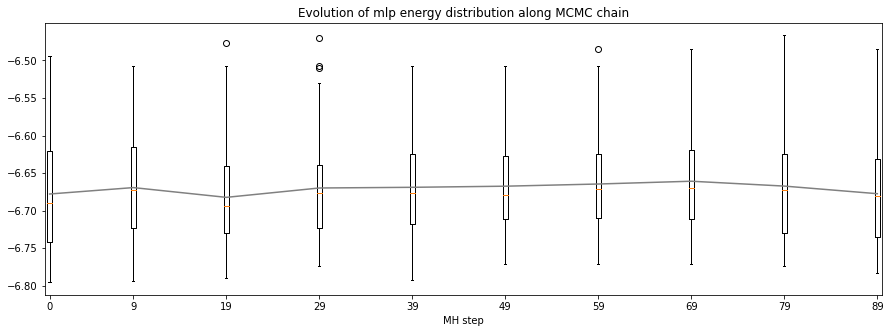

In [96]:
# for i in range(10):
plt.figure(figsize=(15,5))
steps = np.maximum(0, np.arange(10) * 10 - 1)
plt.boxplot([mcmc_run['us'][step, :].detach().numpy() for step in steps], positions=steps)
plt.plot(steps, [mcmc_run['us'][step, :].detach().numpy().mean() for step in steps], '-', c='grey')
plt.title('Evolution of mlp energy distribution along MCMC chain')
plt.xlabel('MH step')